In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

ModuleNotFoundError: No module named 'kagglehub'

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [1]:
import pandas as pd

df = pd.read_csv('../datasets/retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


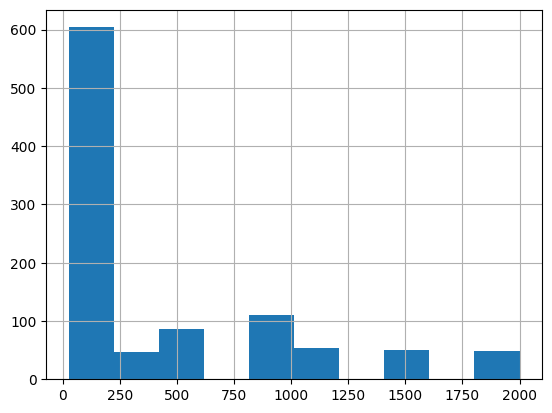

In [4]:
import matplotlib.pyplot as plt

df['Total Amount'].hist()

plt.show()

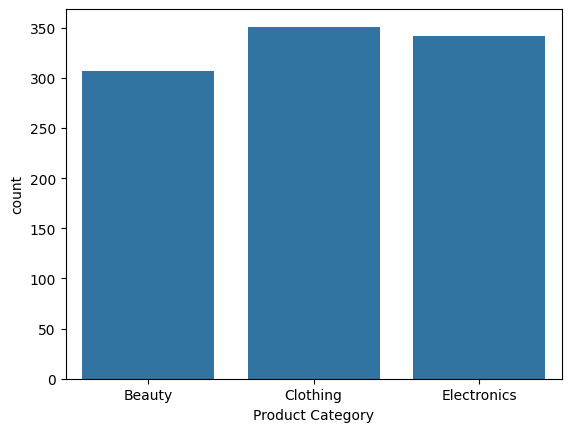

In [9]:
import seaborn as sns

sns.countplot(x='Product Category', data=df)

plt.show()

In [10]:
X = df[['Quantity', 'Price per Unit', 'Age']]

y = df['Total Amount']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(800, 3)
(200, 3)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

LinearRegression()

In [15]:
prediction = model.predict(X_test)

print(prediction[:5])

[1339.95910882   46.08170522  481.77205118  340.32745977 1543.9311768 ]


In [16]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': prediction
})

print(result.head())

     Actual    Predicted
521    1500  1339.959109
737     100    46.081705
740     300   481.772051
660     100   340.327460
411    2000  1543.931177


In [17]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, prediction)

print("Mean Absolute Error:", error)


Mean Absolute Error: 173.1161021544195


In [19]:
new_data = pd.DataFrame({
    'Quantity': [3],
    'Price per Unit': [500],
    'Age': [25]
})

result = model.predict(new_data)

print("Predicted Total Amount:", result[0])

result = model.predict(new_data)

print("Predicted Total Amount:", result[0])

Predicted Total Amount: 1358.947744100052
Predicted Total Amount: 1358.947744100052


In [20]:
import joblib

joblib.dump(model, 'sales_prediction_model.pkl')

['sales_prediction_model.pkl']

In [21]:
import os

print(os.getcwd())

c:\Users\chand\OneDrive\Desktop\ShopVision AI\notebooks


In [22]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print(f"Accuracy: {r2 * 100:.2f}%")

R2 Score: 0.856877226425043
Accuracy: 85.69%
